# Miguel Baños Baladrón
# Pablo Díaz Blanco
### Grupo de prácticas 1.1
### Principios de Visión por Computador

# Ejercicio 1.- Segmentación de carreteras en imagen aérea de alta resolución

# Importaciones y configuración global

In [3]:
!pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   --- ------------------------------------ 6.0/72.0 MB 36.5 MB/s eta 0:00:02
   -------- ------------------------------- 14.4/72.0 MB 37.4 MB/s eta 0:00:02
   ------------ --------------------------- 22.0/72.0 MB 36.3 MB/s eta 0:00:02
   ----------------- ---------------------- 30.9/72.0 MB 37.9 MB/s eta 0:00:02
   ---------------------- ----------------- 40.1/72.0 MB 38.7 MB/s eta 0:00:01
   -------------------------- ------------- 47.4/72.0 MB 39.2 MB/s eta 0:00:01
   ------------------------------- -------- 55.8/72.0 MB 39.1 MB/s eta 0:00:01
   ----------------------------------- ---- 64.7/72.0 MB 39.5 MB/s eta 0:00:01
   ---------------------------------------  71.8/72.0 MB 39.7 MB/s eta 0:00:01
   ---------------------------------------- 72.0/72.0 MB 36.2 MB/s  0:00:02



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## Instalar paquetes

In [ ]:
!pip install pandas numpy matplotlib scikit-image scikit-learn joblib 


  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/11.0 MB 7.3 MB/s eta 0:00:02
   --------------- ------------------------ 4.2/11.0 MB 11.1 MB/s eta 0:00:01
   -------------------------- ------------- 7.3/11.0 MB 12.3 MB/s eta 0:00:01
   ---------------------------------------  10.7/11.0 MB 13.4 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 13.0 MB/s  0:00:00
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)

   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ------------- ----


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports

In [43]:
import os
import pandas as pd
import joblib
import numpy as np
from skimage import io
from skimage.color import rgb2gray
from skimage.filters import sobel_h, sobel_v, sobel, laplace, gaussian, difference_of_gaussians
from skimage.feature import canny
from skimage.morphology import opening, closing, disk, remove_small_objects
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, jaccard_score
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from scipy.ndimage import uniform_filter
from skimage.filters.rank import entropy
from skimage import img_as_ubyte

## Celda de las constantes e hiperparámetros
- Esta sección define los parámetros globales y los hiperparámetros para los modelos que se entrenarán. Se especifican variables como la fracción de datos de entrenamiento (FRAC_TRAIN), la semilla aleatoria (SEED) y la fracción de muestras positivas (FRAC_POS) utilizadas para el balanceo de los datos. Además, se define una lista de características (FEATURE_LIST) que incluye diversas representaciones de las imágenes de satélite, como los canales RGB, la escala de grises, la magnitud del gradiente de Sobel, el operador Laplacian of Gaussian y el operador Canny, junto con las características derivadas de FRENDIS.

- Los hiperparámetros de los modelos incluyen configuraciones para Random Forest (RF), HistGradientBoosting (HGB), XGBoost, Naive Bayes (GNB), k-Nearest Neighbors (KNN) y Logistic Regression (LogReg).

In [44]:
FRAC_TRAIN   = 0.2          
SEED         = 42  
FRAC_POS = 0.2         
FEATURE_LIST = [
    "rgb",
    "gray",
    "sobel_mag",
    "log",
    "canny",
    "frendis",
]

rf_hyperparams = [
    (120, 7),    
    (180, 6),   
    (250, 9),    
    (100, 8),   
    (200, 7),  
]

hgb_hyperparams = [
    (8,  0.1, 200),   
    (10, 0.1, 200),   
    (10, 0.05, 300),  
    (12, 0.05, 300),  
    (6,  0.1, 300),   
]

xgb_hyperparams = [
    (200, 6),
    (300, 6),
    (300, 8),
    (400, 8),
    (500, 10),
]

gnb_hyperparams = [
    (1e-9,),  
]

knn_hyperparams = [     
    (9,),     
]

logreg_hyperparams = [
    ("lbfgs", 1.0), 
]

# Carga y preparación de datos
## Carga de imágenes y máscaras
- Este bloque de código carga todo el dataset. A continuación, define las rutas donde están las imágenes de satélite y sus máscaras, lista los archivos de ambas carpetas y los ordena alfabéticamente para que cada imagen se alinea con su etiqueta. Después, recorre ambos listados en paralelo, lee cada imagen y su máscara y se añaden a dos listas. Por último, se convierten las listas en arrays de numpy.

In [45]:
BASE_PATH = "roads" # carpeta base 
SAT_PATH = os.path.join(BASE_PATH, "sat") # subcarpeta con las fotos de satélite
GT_PATH  = os.path.join(BASE_PATH, "gt") # subcarpeta con las máscaras binarias de etiqueta

sat_images = []
gt_masks = []

# Obtenemos los nombres de los archivos ordenados para hacer coincidir imagen con etiqueta
sat_files = []
for f in os.listdir(SAT_PATH):
    sat_files.append(f)
sat_files = sorted(sat_files)

gt_files  = []
for f in os.listdir(GT_PATH):  
    gt_files.append(f)
gt_files = sorted(gt_files)

# Para cada par imagen-etiqueta, accedemos a ellos, los leemos y los añadimos a sus correspondiente lista.
for sat, gt in zip(sat_files, gt_files):
    sat_path = os.path.join(SAT_PATH, sat)
    gt_path  = os.path.join(GT_PATH, gt)
    sat_img = io.imread(sat_path)
    gt_img  = io.imread(gt_path)
    sat_images.append(sat_img)
    gt_masks.append(gt_img)

# Se transforman en arrays de numpy para operar más rápido con ellas.
sat_images = np.array(sat_images)
gt_masks   = np.array(gt_masks)

print("Datos cargados correctamente:")
print("Satélites:", sat_images.shape)
print("Máscaras:", gt_masks.shape)

Datos cargados correctamente:
Satélites: (20, 1500, 1500, 3)
Máscaras: (20, 1500, 1500)


## Carga de modelos ya entrenados
- Para reducir el número de modelos que se podrán visualizar una vez terminada la práctica y mostrar únicamente aquellos que aportan información relevante, creamos una celda en la que cargamos los modelos ya entrenados de sus respectivas carpetas y seleccionamos posteriormente los modelos que queremos visualizar.

In [46]:
models_dirs = [
    "C:/Users/Usuario/OneDrive/Escritorio/uni/Vision por Computacion Aplicada/Practicas/PVC/ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases",  
    "C:/Users/Usuario/OneDrive/Escritorio/uni/Vision por Computacion Aplicada/Practicas/PVC/ejecuciones_extras", 
    "C:/Users/Usuario/OneDrive/Escritorio/uni/Vision por Computacion Aplicada/Practicas/PVC/modelos_carretera_hiperparametros_completos_RF_HGB_KNN_GNB_LR", 
    "C:/Users/Usuario/OneDrive/Escritorio/uni/Vision por Computacion Aplicada/Practicas/PVC/modelos_carretrea_balanceo_con_pesos", 
]

loaded_models_folder_1 = []
loaded_models_folder_2 = []
loaded_models_folder_3 = []
loaded_models_folder_4 = []

for folder_idx, models_dir in enumerate(models_dirs):
    model_files = [f for f in os.listdir(models_dir) if f.endswith('.joblib')]  

    for model_file in model_files:
        model_path = os.path.join(models_dir, model_file)
        model = joblib.load(model_path)

        if folder_idx == 0:
            loaded_models_folder_1.append({"model": model, "name": model_file})
        elif folder_idx == 1:
            loaded_models_folder_2.append({"model": model, "name": model_file})
        elif folder_idx == 2:
            loaded_models_folder_3.append({"model": model, "name": model_file})
        elif folder_idx == 3:
            loaded_models_folder_4.append({"model": model, "name": model_file})

#print("Modelos cargados en la carpeta 1:")
#for idx, model_info in enumerate(loaded_models_folder_1):
#    print(f"Índice {idx}: {model_info['name']}")

#print("\nModelos cargados en la carpeta 2:")
#for idx, model_info in enumerate(loaded_models_folder_2):
#    print(f"Índice {idx}: {model_info['name']}")

print("\nModelos cargados en la carpeta 3:")
for idx, model_info in enumerate(loaded_models_folder_3):
    print(f"Índice {idx}: {model_info['name']}")

#print("\nModelos cargados en la carpeta 4:")
#for idx, model_info in enumerate(loaded_models_folder_4):
#    print(f"Índice {idx}: {model_info['name']}")



Modelos cargados en la carpeta 3:
Índice 0: GNB_vs1e-09.joblib
Índice 1: HGB_d10_lr0.05_it300.joblib
Índice 2: HGB_d10_lr0.1_it200.joblib
Índice 3: HGB_d12_lr0.05_it300.joblib
Índice 4: HGB_d6_lr0.1_it300.joblib
Índice 5: HGB_d8_lr0.1_it200.joblib
Índice 6: KNN_n3.joblib
Índice 7: KNN_n5.joblib
Índice 8: KNN_n7.joblib
Índice 9: KNN_n9.joblib
Índice 10: LogReg_solverlbfgs_C1.0.joblib
Índice 11: RF_n100_d10.joblib
Índice 12: RF_n150_d8.joblib
Índice 13: RF_n200_d10.joblib
Índice 14: RF_n200_d12.joblib
Índice 15: RF_n300_d12.joblib


In [63]:
selected_models = []  

indices_to_load = [
    [3],  # De la carpeta 1, cargar el modelo en índice 0
    [],  # De la carpeta 2, cargar el modelo en índice 2
    [], # De la carpeta 3, cargar el modelo en índice 10
    [],   # De la carpeta 4, no cargar ningún modelo
]

for folder_idx, models_dir in enumerate(models_dirs):
    model_files = sorted([f for f in os.listdir(models_dir) if f.endswith('.joblib')])
    
    for idx in indices_to_load[folder_idx]:
        if idx < len(model_files):  
            model_file = model_files[idx]
            model_path = os.path.join(models_dir, model_file)
            model = joblib.load(model_path)  
            selected_models.append({"model": model, "name": model_file.split('.')[0]})  

print("Modelos cargados:")
for model_info in selected_models:
    print(model_info['name'])


Modelos cargados:
HGB_d12_lr0


## Preprocesado
- Primero inspecciona los valores de las máscaras para ver los distintos formatos. Para asegurarse de que son máscaras binarias correctas, convierte todos los valores mayores que 0 en 1.

In [48]:
# Comprobamos los valores de las máscaras, las necesitamos en 0 o en 1.
print("Valores máscara original:", np.unique(gt_masks))

# Así, convertimos todo lo que es 0 en False, y lo mayor a 0 en True. Pasándolo a uint8, False pasa a 0 y True a 1, como buscamos.
gt_masks_p = (gt_masks > 0).astype(np.uint8)
print("Máscara que usaremos:", np.unique(gt_masks_p))

# Ahora con las imágenes de satélite
print("Mínimo original imágenes de satélite:", sat_images.min())
print("Máximo original imágenes de satélite:", sat_images.max())

# Las convertimos a float32 y normalizamos a [0, 1]
sat_images_p = sat_images.astype(np.float32) / 255.0

# Comprobamos
print("Mínimo procesado imágenes de satélite:", sat_images_p.min())
print("Máximo procesado imágenes de satélite:", sat_images_p.max())

Valores máscara original: [  0 255]
Máscara que usaremos: [0 1]
Mínimo original imágenes de satélite: 0
Máximo original imágenes de satélite: 255
Mínimo procesado imágenes de satélite: 0.0
Máximo procesado imágenes de satélite: 1.0


# Particionado del dataset
## División en train/val/test
- En este bloque se realiza el particionado del dataset. Se barajan los índices de todas las imágenes y se dividen de forma controlada en tres subconjuntos: train, validation y test.Debido a que se fija la semilla aleatoria, la división es reproducible en todas las ejecuciones.

In [49]:
N = sat_images_p.shape[0] 

indices = np.arange(N)      # [0, 1, 2, ..., 19]
np.random.seed(42)          # para que siempre salga igual
np.random.shuffle(indices)  # baraja los índices

train_idx = indices[:16]        # 16 primeros -> TRAIN
val_idx   = indices[16:18]      # 2 siguientes -> VAL
test_idx  = indices[18:20]      # 2 últimos  -> TEST

print("Índices de las imágenes de entrenamiento:", train_idx)
print("Índices de las imágenes de validación:",   val_idx)
print("Índices de las imágenes de test:",  test_idx)

Índices de las imágenes de entrenamiento: [ 0 17 15  1  8  5 11  3 18 16 13  2  9 19  4 12]
Índices de las imágenes de validación: [ 7 10]
Índices de las imágenes de test: [14  6]


## Construcción de los subconjuntos para train/val/test
- Una vez definidos los índices de cada partición, se crean los subconjuntos correspondientes tanto para las imágenes de satélite como para sus máscaras. Este paso organiza correctamente los datos antes del preprocesado y del entrenamiento del clasificador.

In [50]:
sat_train = sat_images_p[train_idx] # imágenes de satélite de entrenamiento
sat_val   = sat_images_p[val_idx] # de validación 
sat_test  = sat_images_p[test_idx] # de test

gt_train = gt_masks_p[train_idx]
gt_val   = gt_masks_p[val_idx]
gt_test  = gt_masks_p[test_idx]

print("Train:", sat_train.shape, gt_train.shape) 
print("Val:",   sat_val.shape,   gt_val.shape)
print("Test:",  sat_test.shape,  gt_test.shape)

Train: (16, 1500, 1500, 3) (16, 1500, 1500)
Val: (2, 1500, 1500, 3) (2, 1500, 1500)
Test: (2, 1500, 1500, 3) (2, 1500, 1500)


# Definición de funciones de características
## FReNDiS
- compute_frendis_maps(gray, window=9): Esta función genera el bloque de características FRENDIS, un conjunto de descriptores de textura local basados en estadísticas e información presentes en los apuntes del curso. Para cada imagen se calculan mapas de media local, varianza local, entropía local y gradiente local promedio, utilizando ventanas deslizantes que capturan la estructura y complejidad de la región alrededor de cada píxel. Parámetros:
    1. gray: array con las imágenes en escala de grises, de tamaño (N, H, W).
    2. window: tamaño de la vecindad cuadrada utilizada para calcular los estadísticos locales (por defecto 9).

In [51]:
def compute_frendis_maps(gray, window = 9):
    N, H, W = gray.shape
    size_2d = (1, window, window)

    local_mean = uniform_filter(gray, size=size_2d)

    local_var = uniform_filter(gray**2, size=size_2d) - local_mean**2

    local_entropy = np.empty_like(gray, dtype=np.float32)
    selem = disk(window // 2)
    for i in range(N):
        g_u8 = img_as_ubyte(gray[i])
        local_entropy[i] = entropy(g_u8, selem)
                            
    grad_x = np.empty_like(gray)
    grad_y = np.empty_like(gray)

    for i in range(N):
        grad_x[i] = sobel_h(gray[i])
        grad_y[i] = sobel_v(gray[i])

    grad_mag = np.sqrt(grad_x**2 + grad_y**2)
    local_grad = uniform_filter(grad_mag, size=size_2d)

    frendis = np.stack([local_mean, local_var, local_entropy, local_grad], axis=-1)

    return frendis

## Función para construir vectores de características
- extract_features(sat_images_p): esta función genera las características básicas que se usarán para entrenar el clasificador. Se extraen los canales RGB, se convierten a escala de grises y se calculan distintos mapas útiles para detectar carreteras, como la magnitud del gradiente de sobel, el operador Laplacian of Gaussian y el mapa Canny. Finalmente se guardan todas las características en un diccionario. Los parámetros:
    1. sat_images_p: array de imágenes de satélite preprocesadas.

In [52]:
def extract_features(sat_images_p):
    N, H, W, _ = sat_images_p.shape

    # Canales RGB
    R = sat_images_p[:, :, :, 0]
    G = sat_images_p[:, :, :, 1]
    B = sat_images_p[:, :, :, 2]

    # Valor de gris
    gray = rgb2gray(sat_images_p)
 
    sobel_mag = np.empty_like(gray) # magnitud

    for i in range(N):
        sobel_mag[i] = sobel(gray[i])  # magnitud del gradiente de Sobel

    log_resp  = np.empty_like(gray)

    for i in range(N):
        g = gray[i]
        g_smooth = gaussian(g, sigma=1.0)
        log_resp[i] = laplace(g_smooth)

    # Canny
    canny_map = np.empty_like(gray, dtype=np.float32)
    for i in range(N):
        # canny devuelve bool -> lo paso a 0/1
        c = canny(gray[i], sigma=2.0)
        canny_map[i] = c.astype(np.float32)

    frendis_maps = compute_frendis_maps(gray, window=9)
    # Montar diccionario final
    feature_maps = {
        "rgb": sat_images_p,
        "gray": gray,
        "sobel_mag": sobel_mag,
        "log": log_resp,
        "canny": canny_map,
        "frendis": frendis_maps,
    }

    return feature_maps

# Construcción del dataset
## Construcción del vector de características
- build_dataset(): Esta función genera el conjunto de datos final que utilizará el clasificador.
Dado un diccionario de mapas de características y las máscaras de referencia, la función selecciona las features indicadas, comprueba que todas coinciden en tamaño espacial, añade canales cuando es necesario y aplana cada mapa para convertirlo en una matriz 2D donde cada fila corresponde a un píxel y cada columna a una característica. Finalmente, concatena todas las features y genera también el vector de etiquetas asociado. Parámetros:
1. feature_maps: diccionario que contiene cada mapa de características en formato (N, H, W) o (N, H, W, C_feat).
2. gt_masks_p: máscaras binarias procesadas, de shape (N, H, W), usadas como etiquetas.
3. feature_list: lista con los nombres de las características que deben incluirse en el dataset final.

In [53]:
def build_dataset(feature_maps, gt_masks_p, feature_list):
    N, H, W = gt_masks_p.shape

    feature_columns = []

    for name in feature_list:
        if name not in feature_maps:
            raise ValueError(f"Feature '{name}' no existe en feature_maps")

        fmap = feature_maps[name] 

        # Aseguramos forma (N, H, W, C_feat) siendo C_feat el número de canales de la feature
        if fmap.ndim == 3:  # (N, H, W) -> añadimos un canal
            fmap = fmap[..., np.newaxis]  # (N, H, W, 1) (Una feature escalar como el valor de gris pasa a ser una imagen con un canal, en vez de solo una imagen)
        elif fmap.ndim != 4:
            raise ValueError(f"Mapa de '{name}' tiene ndim={fmap.ndim}, esperado 3 o 4")

        # Comprobamos que coincide en tamaño espacial
        if fmap.shape[0] != N or fmap.shape[1] != H or fmap.shape[2] != W: # Mismo número de imágenes, altura y anchura
            raise ValueError(f"Feature '{name}' tiene shape {fmap.shape}, no compatible con gt_masks {gt_masks_p.shape}")

        # Aplanamos: (N, H, W, C_feat) -> (N*H*W, C_feat)
        c_feat = fmap.shape[-1]
        f_flat = fmap.reshape(N*H*W, c_feat)

        feature_columns.append(f_flat)

    # Concatenamos todas las columnas de features → (N*H*W, D_total)
    X = np.concatenate(feature_columns, axis=1)

    # Etiquetas: (N, H, W) -> (N*H*W,)
    y = gt_masks_p.reshape(-1)

    return X, y

## Función para el balanceo de clases

- make_train_subset: El objetivo de esta función es aplicar un balanceo de clases. En los modelos en los que se quiera tener un número similar de píxeles de cada clase se pone el parámetro balanced como true. Los parámetros son:
    1. X_train: matriz de características.
    2. y_train: etiquetas de los píxeles.
    3. frac: porcentaje de píxeles utilizados para entrenamiento.
    4. balanced: si es True, se aplica el balanceo de clases.
    5. seed: semilla para que la selección aleatoria sea siempre igual.

In [54]:
def make_train_subset(X_train, y_train, frac=0.2, balanced=True, frac_pos = 0.2, seed=42):
    n_total = len(y_train)
    n_sub = int(n_total * frac)

    if not balanced:
        idx = np.random.choice(n_total, size=n_sub, replace=False)
        return X_train[idx], y_train[idx]

    pos_idx = np.where(y_train == 1)[0]
    neg_idx = np.where(y_train == 0)[0]

    n_pos_target = int(n_sub * frac_pos)
    n_neg_target = n_sub - n_pos_target

    n_pos = min(n_pos_target, len(pos_idx))
    n_neg = min(n_neg_target, len(neg_idx))

    pos_sub = np.random.choice(pos_idx, size=n_pos, replace=False)
    neg_sub = np.random.choice(neg_idx, size=n_neg, replace=False)

    idx_sub = np.concatenate([pos_sub, neg_sub])
    np.random.shuffle(idx_sub)

    return X_train[idx_sub], y_train[idx_sub]


# Métricas y utilidades
## Función de métricas utilizadas
- compute_metrics(y_true, y_pred): Esta función calcula y devuelve un conjunto de métricas de evaluación estándar para modelos de clasificación binaria. Utiliza las etiquetas verdaderas (y_true) y las etiquetas predichas (y_pred) para calcular la exactitud (accuracy), precisión (precision), recuperación (recall), F1 (Dice) y Jaccard. Parámetros:
    1. y_true: array de etiquetas verdaderas, de tamaño (N, H, W) o similar.
    2. y_pred: array de etiquetas predichas por el modelo, de tamaño (N, H, W) o similar.

In [55]:
def compute_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Dice (F1)": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Jaccard": jaccard_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

## Postprocesado
- postprocess_mask(mask, min_size, radius): Esta función aplica un proceso de postprocesado a una máscara binaria predicha. El postprocesado incluye dos pasos principales: Eliminación de objetos pequeños: se eliminan los objetos que son más pequeños que un tamaño mínimo especificado (min_size), usando la función remove_small_objects; Cierre morfológico: se aplica una operación de cierre para suavizar los bordes y conectar áreas disjuntas, utilizando un elemento estructurante en forma de disco con el radio especificado (radius), a través de la función closing. Parámetros:
    1. mask: Máscara binaria predicha, de tamaño (N, H, W), que se desea postprocesar.
    2. min_size: Tamaño mínimo de los objetos que deben permanecer en la máscara después del postprocesado.
    3. radius: Radio del disco utilizado para el cierre morfológico, determinando el tamaño de la vecindad para la operación.

In [56]:
def postprocess_mask(mask, min_size, radius):
    mask_bool = mask.astype(bool)

    mask_clean = remove_small_objects(mask_bool, min_size=min_size)

    selem = disk(radius)
    mask_closed = closing(mask_clean, selem)

    return mask_closed.astype(np.uint8)


## Función para la visualización de imágenes
- visualize_results(sat_image, gt_mask, pred_mask_raw, pred_mask_pp):
Esta función visualiza los resultados de la segmentación mostrando cuatro imágenes en un solo gráfico: la imagen de satélite original, la máscara verdadera (ground truth), la máscara predicha sin postprocesado y la máscara predicha después de aplicar el postprocesado. Parámetros:
    1. sat_image: Imagen de satélite original, de tamaño (H, W, 3), que contiene la escena a segmentar.
    2. gt_mask: Máscara verdadera, de tamaño (H, W), utilizada como referencia para comparar los resultados.
    3. pred_mask_raw: Máscara predicha sin postprocesado, de tamaño (H, W), obtenida directamente del modelo.
    4. pred_mask_pp: Máscara predicha con postprocesado, de tamaño (H, W), después de aplicar operaciones morfológicas para mejorar la segmentación.

In [57]:
def visualize_results(sat_image, gt_mask, pred_mask_raw, pred_mask_pp):
    plt.figure(figsize=(20, 5))

    plt.subplot(1, 4, 1)
    plt.title("Imagen de Satélite")
    plt.imshow(sat_image)
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.title("Máscara Verdadera")
    plt.imshow(gt_mask, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.title("Predicción (sin postprocesado)")
    plt.imshow(pred_mask_raw, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.title("Predicción (postprocesada)")
    plt.imshow(pred_mask_pp, cmap='gray')
    plt.axis('off')

    plt.show()


## Guardar modelos
- save_model_and_results(model, model_name, metrics_test, models_dir, csv_path): Esta función guarda el modelo entrenado en un archivo .joblib y actualiza los resultados de la evaluación en un archivo CSV. Primero, guarda el modelo en el directorio especificado, creando el directorio si no existe. Luego, crea o actualiza el archivo CSV con las métricas de evaluación (como accuracy, precision, recall, etc.) del modelo, añadiendo una fila con los resultados correspondientes. Si el CSV ya existe, la función actualiza los resultados para el modelo actual, sustituyendo cualquier fila previa con el mismo nombre de modelo. Parámetros:
    1. model: El modelo entrenado que se va a guardar.
    2. model_name: Nombre que se asignará al modelo para guardarlo.
    3. metrics_test: Diccionario con las métricas de evaluación del modelo en el conjunto de test.
    4. models_dir: Directorio donde se guardará el modelo.
    5. csv_path: Ruta del archivo CSV donde se almacenarán los resultados.

In [58]:
def save_model_and_results(model, model_name: str, metrics_test: dict, models_dir: str = "ejecuciones_extras", csv_path: str = "ejecuciones_extras.csv"):
    
    # Guardar el modelo .joblib
    os.makedirs(models_dir, exist_ok=True)
    model_path = os.path.join(models_dir, f"{model_name}.joblib")
    joblib.dump(model, model_path)
    print(f"Modelo guardado en {model_path}")

    # Crear la fila nueva con las métricas
    new_row = {"Modelo": model_name}
    new_row.update(metrics_test)  # añade Accuracy, Precision, etc.

    # Cargar CSV si existe, si no, crearlo
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)

        # Si ya hay una fila con ese modelo, la sustituimos
        df = df[df["Modelo"] != model_name]
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    else:
        df = pd.DataFrame([new_row])

    # Guardar el CSV actualizado
    df.to_csv(csv_path, index=False)
    print(f"Resultados de test guardados/actualizados en {csv_path}")

    return df 

## Preparación del dataset
- prepare_datasets(feature_list=FEATURE_LIST): Esta función se encarga de preparar los datasets de entrenamiento, validación y test, procesando las imágenes de satélite y extrayendo las características necesarias mediante la función extract_features. Luego, utiliza la función build_dataset para construir las matrices de características (X_train, X_val, X_test) y las etiquetas correspondientes (y_train, y_val, y_test). Una vez que los datos están listos, imprime las dimensiones de los conjuntos de datos generados. Parámetros:
    1. feature_list: Lista de características que se deben incluir en el dataset final (por defecto FEATURE_LIST).

In [59]:
def prepare_datasets(feature_list=FEATURE_LIST):

    # Le das acceso a la función a los datos de entrenamiento, validación y test de fuera de la función
    global X_train, y_train, X_val, y_val, X_test, y_test

    feature_maps_train = extract_features(sat_train)
    feature_maps_val   = extract_features(sat_val)
    feature_maps_test  = extract_features(sat_test)

    X_train, y_train = build_dataset(feature_maps_train, gt_train, feature_list)
    X_val,   y_val   = build_dataset(feature_maps_val,   gt_val,   feature_list)
    X_test,  y_test  = build_dataset(feature_maps_test,  gt_test,  feature_list)

    print("Datasets preparado:")
    print("  X_train:", X_train.shape, " y_train:", y_train.shape)
    print("  X_val:  ", X_val.shape,   " y_val:  ", y_val.shape)
    print("  X_test: ", X_test.shape,  " y_test: ", y_test.shape)


### Creamos el dataset

In [60]:
prepare_datasets()

Datasets preparado:
  X_train: (36000000, 11)  y_train: (36000000,)
  X_val:   (4500000, 11)  y_val:   (4500000,)
  X_test:  (4500000, 11)  y_test:  (4500000,)


# Entrenamiento
## Función de entrenamiento
- train_model(model_cls, model_name, model_kwargs=None, , use_balanced=True, frac=FRAC_TRAIN, seed=SEED): Esta función entrena un modelo, utilizando la clase del modelo proporcionada (model_cls) y los hiperparámetros especificados en model_kwargs. Dependiendo de la opción use_balanced, realiza un submuestreo balanceado en el conjunto de entrenamiento utilizando la función make_train_subset. Después de entrenar el modelo, calcula las métricas de evaluación (como precisión, recall, F1) para los conjuntos de entrenamiento, validación y test. Finalmente, guarda el modelo entrenado y sus resultados en un archivo. Parámetros:
    1. model_cls: Clase del modelo que se va a entrenar.
    2. model_name: Nombre que se asignará al modelo guardado.
    3. model_kwargs: Diccionario con los hiperparámetros del modelo.
    4. use_balanced: Booleano que indica si se debe usar balanceo en el conjunto de entrenamiento (por defecto True).
    5. frac: Fracción de datos de entrenamiento a utilizar (por defecto FRAC_TRAIN).
    6. seed: Semilla para la aleatorización (por defecto SEED).

In [61]:
def train_model(model_cls, model_name, model_kwargs=None, *, use_balanced=True, frac=FRAC_TRAIN, seed=SEED,):

    if model_kwargs is None:
        model_kwargs = {}

    global X_train, y_train, X_val, y_val, X_test, y_test

    if use_balanced:
        X_train_sub, y_train_sub = make_train_subset(
            X_train,
            y_train,
            frac=FRAC_TRAIN,
            balanced=True,
            seed= SEED,
            frac_pos = FRAC_POS
        )
    else:
        X_train_sub, y_train_sub = X_train, y_train

    model = model_cls(**model_kwargs)
    model.fit(X_train_sub, y_train_sub)

    y_train_pred = model.predict(X_train_sub)
    y_val_pred   = model.predict(X_val)
    y_test_pred  = model.predict(X_test)

    metrics_train = compute_metrics(y_train_sub, y_train_pred)
    metrics_val   = compute_metrics(y_val,      y_val_pred)
    metrics_test  = compute_metrics(y_test,     y_test_pred)

    df_global = save_model_and_results(
        model=model,
        model_name=model_name,
        metrics_test=metrics_test,
    )

    return {
        "model": model,
        "metrics_train": metrics_train,
        "metrics_val": metrics_val,
        "metrics_test": metrics_test,
        "df_global": df_global,
    }


### Lista donde guardamos los resultados de todos los modelos

In [44]:
all_model_results = []

## Bucle de entrenamiento

### Bucle de entrenamiento para recorrer los hiperparámetros de RandomForestClassifier
- Este bloque de código entrena múltiples casos del RandomForestClassifier con diferentes combinaciones de hiperparámetros, definidos en una lista. Para cada combinación, se llama a la función train_model para entrenar el modelo y almacenar las métricas de rendimiento (entrenamiento, validación y test) en el diccionario all_model_results. Este proceso permite evaluar y comparar diferentes configuraciones de un mismo modelo y seleccionar la que mejor rendimiento ofrece.

In [45]:
for n_estimators, max_depth in rf_hyperparams:
    model_name = f"RF_n{n_estimators}_d{max_depth}"

    rf_results = train_model(
        model_cls=RandomForestClassifier,
        model_name=model_name,
        model_kwargs=dict(
            n_estimators=n_estimators,
            max_depth=max_depth,
            n_jobs=-1,
            random_state=SEED,
        ),
        use_balanced=True,
    )

    all_model_results.append({
        "family": "RF",
        "name": model_name,
        "model": rf_results["model"],
        "metrics_train": rf_results["metrics_train"],
        "metrics_val": rf_results["metrics_val"],
        "metrics_test": rf_results["metrics_test"],
    })

Modelo guardado en ejecuciones_extras\RF_n120_d7.joblib
Resultados de test guardados/actualizados en ejecuciones_extras.csv
Modelo guardado en ejecuciones_extras\RF_n180_d6.joblib
Resultados de test guardados/actualizados en ejecuciones_extras.csv
Modelo guardado en ejecuciones_extras\RF_n250_d9.joblib
Resultados de test guardados/actualizados en ejecuciones_extras.csv
Modelo guardado en ejecuciones_extras\RF_n100_d8.joblib
Resultados de test guardados/actualizados en ejecuciones_extras.csv
Modelo guardado en ejecuciones_extras\RF_n200_d7.joblib
Resultados de test guardados/actualizados en ejecuciones_extras.csv


## Bucle de entrenamiento sin balanceo 

### Bucle de entrenamiento para recorrer los hiperparámetros de RandomForestClassifier con use_balance = False
- La idea es demostrar el efecto del balanceo de las clases en los resultados. Solo se va a probar en RandomForest porque se entiende que el efecto (subir o bajar rendimiento) será igual en cualquiera que sea el modelo.

In [ ]:
for n_estimators, max_depth in rf_hyperparams:
    model_name = f"RF_n{n_estimators}_d{max_depth}"

    rf_results = train_model(
        model_cls=RandomForestClassifier,
        model_name=model_name,
        model_kwargs=dict(
            n_estimators=n_estimators,
            max_depth=max_depth,
            n_jobs=-1,
            random_state=SEED,
        ),
        use_balanced=False,
    )

    all_model_results.append({
        "family": "RF",
        "name": model_name,
        "model": rf_results["model"],
        "metrics_train": rf_results["metrics_train"],
        "metrics_val": rf_results["metrics_val"],
        "metrics_test": rf_results["metrics_test"],
    })

Modelo guardado en ejecuciones_extras\RF_n120_d7.joblib
Resultados de test guardados/actualizados en ejecuciones_extras.csv


### Bucle de entrenamiento para recorrer los hiperparámetros de HistGradientBoostingClassifier
- Este bloque de código entrena múltiples casos del HistGradientBoostingClassifier con diferentes combinaciones de hiperparámetros, definidos en una lista. Para cada combinación, se llama a la función train_model para entrenar el modelo y almacenar las métricas de rendimiento (entrenamiento, validación y test) en el diccionario all_model_results. Este proceso permite evaluar y comparar diferentes configuraciones de un mismo modelo y seleccionar la que mejor rendimiento ofrece.

In [19]:
for max_depth, learning_rate, max_iter in hgb_hyperparams:
    model_name = f"HGB_d{max_depth}_lr{learning_rate}_it{max_iter}"

    hgb_results = train_model(
        model_cls=HistGradientBoostingClassifier,
        model_name=model_name,
        model_kwargs=dict(
            max_depth=max_depth,
            learning_rate=learning_rate,
            max_iter=max_iter,
            random_state=SEED,
        ),
        use_balanced=True,
    )

    all_model_results.append({
        "family": "HGB",
        "name": model_name,
        "model": hgb_results["model"],
        "metrics_train": hgb_results["metrics_train"],
        "metrics_val": hgb_results["metrics_val"],
        "metrics_test": hgb_results["metrics_test"],
    })

Modelo guardado en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases\HGB_d8_lr0.1_it200.joblib
Resultados de test guardados/actualizados en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases.csv
Modelo guardado en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases\HGB_d10_lr0.1_it200.joblib
Resultados de test guardados/actualizados en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases.csv
Modelo guardado en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases\HGB_d10_lr0.05_it300.joblib
Resultados de test guardados/actualizados en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases.csv
Modelo guardado en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases\HGB_d12_lr0.05_it300.joblib
Resultados de test guardados/actualizados en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases.csv
Modelo guardado en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases\HGB_d6_lr0.1_it300.joblib
Resultados de test guardados/actua

### Bucle de entrenamiento para recorrer los hiperparámetros de XGBClassifier
- Este bloque de código entrena múltiples casos del XGBClassifier con diferentes combinaciones de hiperparámetros, definidos en una lista. Para cada combinación, se llama a la función train_model para entrenar el modelo y almacenar las métricas de rendimiento (entrenamiento, validación y test) en el diccionario all_model_results. Este proceso permite evaluar y comparar diferentes configuraciones de un mismo modelo y seleccionar la que mejor rendimiento ofrece.

In [20]:
for n_estimators, max_depth in xgb_hyperparams:
    model_name = f"XGB_n{n_estimators}_d{max_depth}"

    xgb_results = train_model(
        model_cls=XGBClassifier,
        model_name=model_name,
        model_kwargs=dict(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=0.05,   
            subsample=0.8,
            colsample_bytree=0.8,
            n_jobs=-1,
            tree_method="hist",
            random_state=SEED,
            eval_metric="logloss",   
        ),
        use_balanced=True,  
    )

    all_model_results.append({
        "family": "XGB",
        "name": model_name,
        "model": xgb_results["model"],
        "metrics_train": xgb_results["metrics_train"],
        "metrics_val": xgb_results["metrics_val"],
        "metrics_test": xgb_results["metrics_test"],
    })


Modelo guardado en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases\XGB_n200_d6.joblib
Resultados de test guardados/actualizados en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases.csv
Modelo guardado en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases\XGB_n300_d6.joblib
Resultados de test guardados/actualizados en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases.csv
Modelo guardado en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases\XGB_n300_d8.joblib
Resultados de test guardados/actualizados en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases.csv
Modelo guardado en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases\XGB_n400_d8.joblib
Resultados de test guardados/actualizados en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases.csv
Modelo guardado en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases\XGB_n500_d10.joblib
Resultados de test guardados/actualizados en ejecucion_con_FRENDIS_RF_HGB

### Bucle de entrenamiento para recorrer los hiperparámetros de GaussianNB
- Este bloque de código entrena múltiples casos del GaussianNB con diferentes combinaciones de hiperparámetros, definidos en una lista. Para cada combinación, se llama a la función train_model para entrenar el modelo y almacenar las métricas de rendimiento (entrenamiento, validación y test) en el diccionario all_model_results. Este proceso permite evaluar y comparar diferentes configuraciones de un mismo modelo y seleccionar la que mejor rendimiento ofrece.

In [21]:
for (var_smoothing,) in gnb_hyperparams:
    model_name = f"GNB_vs{var_smoothing}"

    gnb_results = train_model(
        model_cls=GaussianNB,
        model_name=model_name,
        model_kwargs=dict(
            var_smoothing=var_smoothing,
        ),
        use_balanced=True,
    )

    all_model_results.append({
        "family": "GNB",
        "name": model_name,
        "model": gnb_results["model"],
        "metrics_train": gnb_results["metrics_train"],
        "metrics_val": gnb_results["metrics_val"],
        "metrics_test": gnb_results["metrics_test"],
    })


Modelo guardado en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases\GNB_vs1e-09.joblib
Resultados de test guardados/actualizados en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases.csv


### Bucle de entrenamiento para recorrer los hiperparámetros de KNeighborsClassifier
- Este bloque de código entrena múltiples casos del KNeighborsClassifier con diferentes combinaciones de hiperparámetros, definidos en una lista. Para cada combinación, se llama a la función train_model para entrenar el modelo y almacenar las métricas de rendimiento (entrenamiento, validación y test) en el diccionario all_model_results. Este proceso permite evaluar y comparar diferentes configuraciones de un mismo modelo y seleccionar la que mejor rendimiento ofrece.

In [22]:
for (n_neighbors,) in knn_hyperparams:
    model_name = f"KNN_n{n_neighbors}"

    knn_results = train_model(
        model_cls=KNeighborsClassifier,
        model_name=model_name,
        model_kwargs=dict(
            n_neighbors=n_neighbors,
            weights="distance",
            n_jobs=-1,
        ),
        use_balanced=True,
    )

    all_model_results.append({
        "family": "KNN",
        "name": model_name,
        "model": knn_results["model"],
        "metrics_train": knn_results["metrics_train"],
        "metrics_val": knn_results["metrics_val"],
        "metrics_test": knn_results["metrics_test"],
    })

Modelo guardado en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases\KNN_n9.joblib
Resultados de test guardados/actualizados en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases.csv


### Bucle de entrenamiento para recorrer los hiperparámetros de LogisticRegression
- Este bloque de código entrena múltiples casos del LogisticRegression con diferentes combinaciones de hiperparámetros, definidos en una lista. Para cada combinación, se llama a la función train_model para entrenar el modelo y almacenar las métricas de rendimiento (entrenamiento, validación y test) en el diccionario all_model_results. Este proceso permite evaluar y comparar diferentes configuraciones de un mismo modelo y seleccionar la que mejor rendimiento ofrece.

In [23]:
for solver, C in logreg_hyperparams:
    model_name = f"LogReg_solver{solver}_C{C}"

    logreg_results = train_model(
        model_cls=LogisticRegression,
        model_name=model_name,
        model_kwargs=dict(
            solver=solver,
            C=C,
            max_iter=500,
            random_state=SEED,
            n_jobs=-1,
        ),
        use_balanced=True,
    )

    all_model_results.append({
        "family": "LogReg",
        "name": model_name,
        "model": logreg_results["model"],
        "metrics_train": logreg_results["metrics_train"],
        "metrics_val": logreg_results["metrics_val"],
        "metrics_test": logreg_results["metrics_test"],
    })

Modelo guardado en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases\LogReg_solverlbfgs_C1.0.joblib
Resultados de test guardados/actualizados en ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases.csv


## Visualización de los modelos actuales

- Evaluación de modelos y visualización de resultados: Este bloque de código evalúa el rendimiento de los modelos que están actualmente entrenados en el kernel utilizando un conjunto de imágenes de prueba. Para cada modelo en la lista all_model_results, se obtiene la predicción para una imagen específica (sat_image). La predicción se calcula por píxel, y luego se reconstruye la máscara predicha. Después, se aplica un postprocesado a la máscara para mejorar la segmentación, como la eliminación de objetos pequeños y el cierre morfológico. Finalmente, se visualizan los resultados, mostrando la imagen de satélite original, la máscara verdadera, la máscara predicha sin postprocesado y la máscara postprocesada.

In [1]:
idx = 0

sat_image = sat_test[idx]
gt_mask   = gt_test[idx]

# Preparamos la imagen en formato batch (1, H, W, 3)
sat_batch = sat_image[None, ...]

# Extraemos features de ESA imagen
feature_maps_img = extract_features(sat_batch)

# Construimos X solo para esa imagen
X_img, _ = build_dataset(feature_maps_img, gt_mask[None, ...], FEATURE_LIST)

for info in all_model_results:
    model = info["model"]
    model_name = info["name"]
    # Predicción por píxel
        
    print(f"Modelo: {model_name}")

    y_pred = model.predict(X_img)

    # Reconstruimos la máscara
    pred_mask_raw = y_pred.reshape(gt_mask.shape)

    # Postprocesamos la máscara
    pred_mask_pp = postprocess_mask(pred_mask_raw, min_size=300, radius=2)

    visualize_results(sat_image, gt_mask, pred_mask_raw, pred_mask_pp)

NameError: name 'sat_test' is not defined

## Visualización de los modelos ya entrenados

- El funcionamiento de esta celda es exactamente igual a la de visualización anterior, con la única diferencia de que recorren listas de modelos distintas. El objetivo de diferenciar entre una y otra es que esta visualización se utilizará para mostrar los mejores modelos que ya han sido entrenados anteriormente y están actualmente guardados en carpetas. La idea es mostrar la imagen real, la máscara y luego las máscaras predichas con y sin postprocesado de los mejores modelos que resultaron durante el proceso global de entrenamiento.

Modelo: HGB_d12_lr0


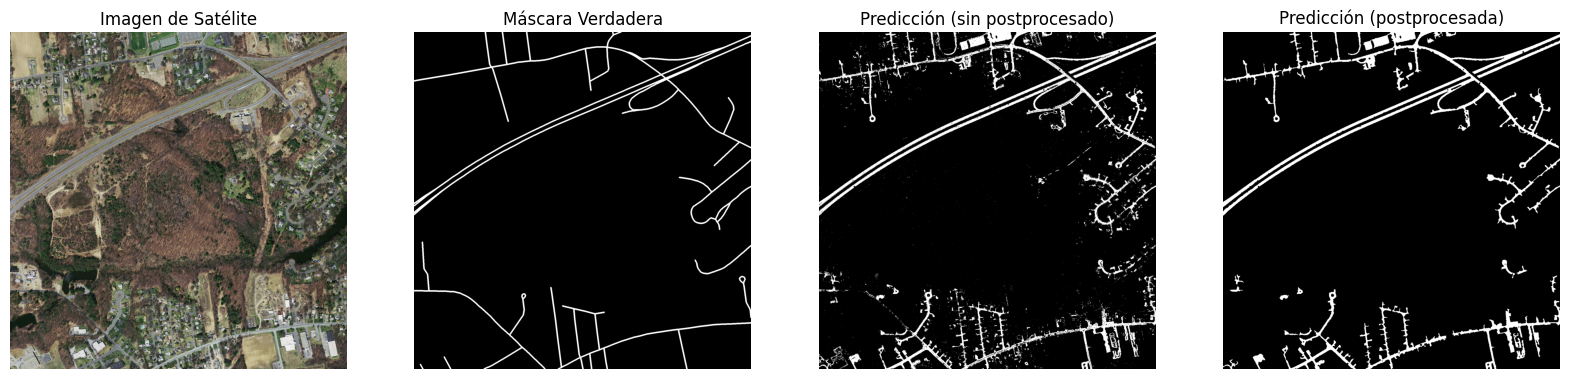

In [64]:
idx = 0
sat_image = sat_test[idx]
gt_mask = gt_test[idx]

sat_batch = sat_image[None, ...]

feature_maps_img = extract_features(sat_batch)

X_img, _ = build_dataset(feature_maps_img, gt_mask[None, ...], FEATURE_LIST)

for model_info in selected_models:  
    model = model_info["model"]
    model_name = model_info["name"]
    
    print(f"Modelo: {model_name}")
    
    y_pred = model.predict(X_img)

    pred_mask_raw = y_pred.reshape(gt_mask.shape)

    pred_mask_pp = postprocess_mask(pred_mask_raw, min_size=300, radius=2)

    visualize_results(sat_image, gt_mask, pred_mask_raw, pred_mask_pp)


# Resultados de los experimentos

## Primera ejecución sin implementar el conjunto de características FReNDiS

In [ ]:
df_resultados = pd.read_csv("resultados_hiperparametros_completos_RF_HGB_KNN_GNB_LR.csv")
df_resultados

,Modelo,Accuracy,Precision,Recall,Dice (F1),Jaccard
0,RF_n100_d10,0.941361,0.299924,0.741176,0.427042,0.271489
1,RF_n200_d10,0.941199,0.299424,0.742201,0.426704,0.271216
2,RF_n200_d12,0.939327,0.294613,0.758692,0.424417,0.269372
3,RF_n300_d12,0.939230,0.294432,0.759928,0.424423,0.269376
4,RF_n150_d8,0.944559,0.309218,0.713454,0.431444,0.275058
5,HGB_d8_lr0.1_it200,0.934547,0.281489,0.785781,0.414494,0.261427
6,HGB_d10_lr0.1_it200,0.934626,0.282013,0.787409,0.415288,0.262059
7,HGB_d10_lr0.05_it300,0.934484,0.281415,0.786700,0.414542,0.261465
8,HGB_d12_lr0.05_it300,0.934592,0.281376,0.784092,0.414136,0.261142
9,HGB_d6_lr0.1_it300,0.934692,0.281968,0.785683,0.414999,0.261829


## Segunda ejecución añadiendo en los modelos que lo permiten un balanceo de clases

In [22]:
df_resultados = pd.read_csv("resultados_modelos_balanceo_con_pesos.csv")
df_resultados

,Modelo,Accuracy,Precision,Recall,Dice (F1),Jaccard
0,RF_n100_d10,0.865062,0.168034,0.905221,0.283451,0.165128
1,RF_n200_d10,0.866757,0.169838,0.905153,0.286011,0.166868
2,RF_n200_d12,0.874341,0.178777,0.907723,0.298721,0.175586
3,RF_n300_d12,0.874012,0.178397,0.907821,0.298195,0.175223
4,RF_n150_d8,0.842300,0.146681,0.902688,0.252356,0.144398
5,HGB_d8_lr0.1_it200,0.876063,0.180899,0.908055,0.301695,0.177645
6,HGB_d10_lr0.1_it200,0.876761,0.181773,0.908183,0.302917,0.178493
7,HGB_d10_lr0.05_it300,0.876344,0.181334,0.908771,0.302340,0.178092
8,HGB_d12_lr0.05_it300,0.876441,0.181495,0.909095,0.302581,0.178259
9,HGB_d6_lr0.1_it300,0.876726,0.181658,0.907625,0.302726,0.178360


## Ejecución principal probando todos los modelos finales sin implementar el balanceo y aplicando FReNDiS

In [26]:
df_resultados = pd.read_csv("ejecucion_con_FRENDIS_RF_HGB_XGB_LR_GNB_sin_balanceo_clases.csv")
df_resultados

,Modelo,Accuracy,Precision,Recall,Dice (F1),Jaccard
0,RF_n100_d10,0.944805,0.318093,0.762468,0.448908,0.289414
1,RF_n200_d10,0.944558,0.317062,0.762973,0.447966,0.288632
2,RF_n200_d12,0.943034,0.314199,0.788125,0.449283,0.289726
3,RF_n300_d12,0.943083,0.314486,0.788660,0.449664,0.290043
4,RF_n150_d8,0.947916,0.326398,0.720585,0.449286,0.289729
5,HGB_d8_lr0.1_it200,0.939318,0.303432,0.816690,0.442469,0.284084
6,HGB_d10_lr0.1_it200,0.939368,0.303518,0.815989,0.442458,0.284074
7,HGB_d10_lr0.05_it300,0.939440,0.303823,0.816170,0.442808,0.284363
8,HGB_d12_lr0.05_it300,0.939271,0.303368,0.817497,0.442520,0.284126
9,HGB_d6_lr0.1_it300,0.939416,0.303713,0.816057,0.442675,0.284253


## Ejecución probando combinaciones de modelos extras
- Como aclaración, esta ejecución será realizada únicamente con RandomForest. Esto no es porque esta ejecución solo busca encontrar unos mejores resultados, y como el mejor modelo era un RandomForest, no existen motivos para probar otro modelo a sabiendas de que no van a mejorar. Por otro lado, se entiende que, si use_balanced tendrá el mismo efecto en cualquier modelo, es decir, si mejora este RandomForest, también debería de mejorar el resto, y si empeora, ocurriría igual. Si tras el experimento vemos que las métricas mejoran, haríamos una última ejecución sin este balanceo. 

- Esta última ejecución tendrá dos objetivos. El primero, vamos a utilizar un nuevo conjunto de hiperparámetros el cual sea similar al del mejor modelo encontrado en la ejecución anterior (RF_n150_d8) para ver si logramos mejorar los resultados.

- Por otra parte, para demostrar el efecto del balanceo de clases que aplica la función make_train_subset(), vamos a ejecutar el mismo conjunto de hiperparámetros pero utilizando use_balanced = False, así podremos comparar los resultados fácilmente sin que un conjunto de hiperparámetros sea el responsable de los resultados distintos.

In [4]:
df_resultados = pd.read_csv("ejecuciones_extras.csv")
df_resultados

,Modelo,Accuracy,Precision,Recall,Dice (F1),Jaccard
0,RF_n180_d6,0.951944,0.339689,0.667388,0.450222,0.290508
1,RF_n250_d9,0.945480,0.318350,0.744100,0.445920,0.286935
2,RF_n100_d8,0.948157,0.327706,0.721203,0.450645,0.290860
3,RF_n200_d7,0.949905,0.333567,0.700551,0.451942,0.291941
4,RF_n120_d7,0.970516,0.000000,0.000000,0.000000,0.000000
